In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Download and read dataset iris.csv. Import necessary files to implement
Gaussian Naive Bayes classification. Perform Label encoding with required
columns. Implement Gaussian Naive Bayes classification. Print confusion
matrix and classification report.

In [ ]:
import pandas as pd
import numpy as np 


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

df= pd.read_csv("./Datasets/iris.csv")

# print upper 5 data
print(df.head())
# print lower 5 data
print(df.info())

# print types
print(df.dtypes)

X= df.iloc[:,:-1]
y= df.iloc[:,-1]

X_train , X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

le = LabelEncoder()
y= le.fit_transform(y)

model = GaussianNB()
model.fit(X_train,y_train)

y_pred= model.predict(X_test)

print("classification_report: ", classification_report(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test,y_pred))

# 4 Import chd.csv dataset and visualize the data to get an insight on building
the model. Specifying the columns as predictor and target variable. Split the
data in training and test set in 70:30 ratio. Built model using
sklearn.linear_model.LogisticRegression class. Train the model using the
training data. Fetch the intercept and the coefficients of the model. Creating
sample data. Predicting the probabilities for each of the class labels.

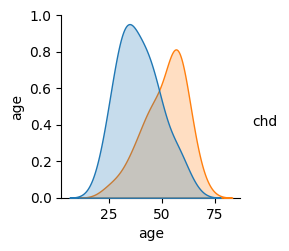

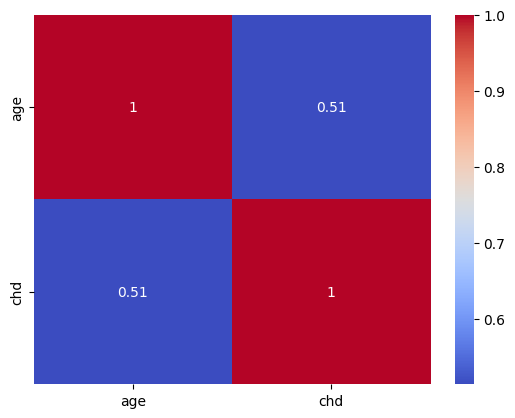

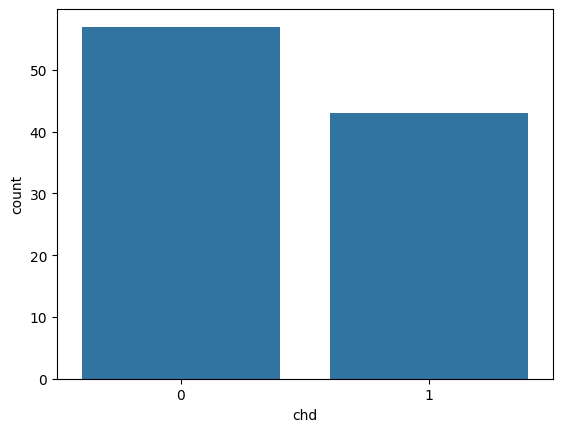

Intercept: [-5.70885812]
Coefficients: [[0.11832747]]
Probabilities:
 [[0.96585207 0.03414793]
 [0.95199828 0.04800172]
 [0.94629249 0.05370751]
 [0.93995126 0.06004874]
 [0.93995126 0.06004874]]
Predictions: [0 0 0 0 0]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression





# Load dataset
df = pd.read_csv("./Datasets/chd_data.csv")

# Visualize
sns.pairplot(df, hue='chd'); plt.show()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm'); plt.show()
sns.countplot(x='chd', data=df); plt.show()

# Define X and y
X = df.drop('chd', axis=1)
y = df['chd']

# Split 70:30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Intercept & coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Sample data
sample_data = X.iloc[:5]

# Predict probabilities
probs = model.predict_proba(sample_data)
print("Probabilities:\n", probs)

# Predict classes
preds = model.predict(sample_data)
print("Predictions:", preds)

## 2) Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize
purchased and not_purchased data distribution based on age and estimated
salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the
customer will purchase a mobile or not.

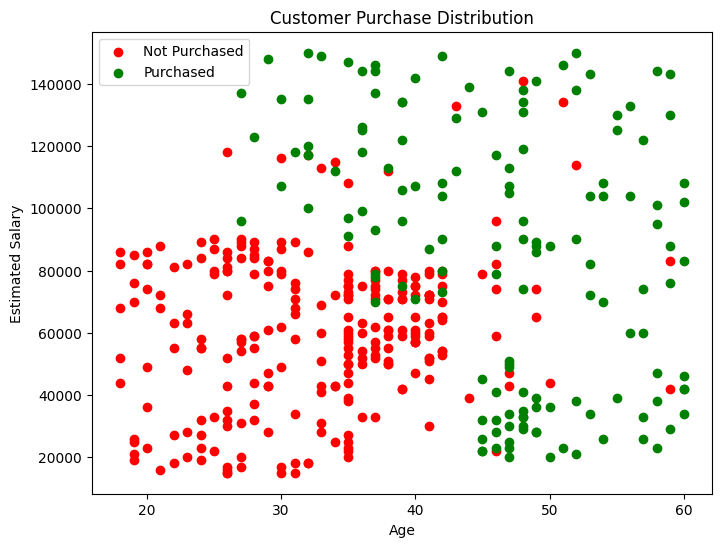

Accuracy: 0.925
Will NOT Purchase


c:\Users\RKU Student\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('./Datasets/mobile.csv')

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df[df['Purchased']==0]['Age'], df[df['Purchased']==0]['EstimatedSalary'], color='red', label='Not Purchased')
plt.scatter(df[df['Purchased']==1]['Age'], df[df['Purchased']==1]['EstimatedSalary'], color='green', label='Purchased')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Customer Purchase Distribution')
plt.legend()
plt.show()

# Features & target
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction & accuracy
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# New prediction
new_customer = scaler.transform([[30, 50000]])
prediction = knn.predict(new_customer)

print("Will Purchase" if prediction[0] == 1 else "Will NOT Purchase")

## 3) Develop Simple Linear Regression.

Develop Simple Linear Regression with help of computer.csv dataset. Fit the
model with the data and fetching intercept and coefficient. Visualize Models
using pyplot. Compute the Coefficient of Determination to find accuracy.

Intercept: 4.161654135338296
Coefficient: 15.508771929824569
R^2 Score (Accuracy): 0.9874371980620736


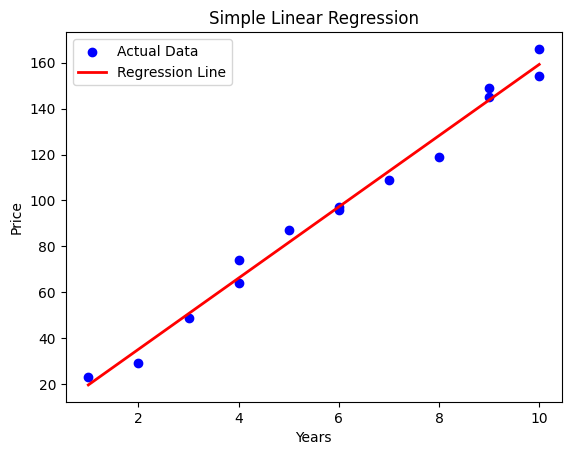

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Load dataset
df = pd.read_csv("./Datasets/computers.csv")
df.head()

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Create and fit model
model = LinearRegression()
model.fit(X, y)

# Fetch intercept and coefficient
intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept:", intercept)
print("Coefficient:", coefficient)

# Predictions
y_pred = model.predict(X)

# Compute R^2 score
r2 = r2_score(y, y_pred)
print("R^2 Score (Accuracy):", r2)

# Visualization
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years')
plt.ylabel('Price')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()
